In [2]:
# Task 1 - Vectorize It

import numpy as np
import time

prices = [
    25, 40, 55, 30, 75,
    100, 45, 60, 85, 20,
    35, 50, 120, 65, 90,
    15, 70, 110, 48, 80
]

# 1
tax_rate = 0.08
taxed_prices_loop = []

for price in prices:
    taxed_prices_loop.append(price * (1 + tax_rate))

print("Loop-based taxed prices:")
print(taxed_prices_loop)


# 2
prices_array = np.array(prices)

taxed_prices_vectorized = prices_array * (1 + tax_rate)

print("\nVectorized taxed prices:")
print(taxed_prices_vectorized)

print("\nResults are identical:")
print(np.allclose(taxed_prices_loop, taxed_prices_vectorized))

# 3

threshold = 50

prices_above_threshold = taxed_prices_vectorized[
    taxed_prices_vectorized > threshold
]

print("\nTaxed prices above", threshold, ":")
print(prices_above_threshold)

print("\nAll selected values are above threshold:")
print(np.all(prices_above_threshold > threshold))

# 4

data = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [90, 100, 110, 120]
])

# Row sums
row_sums = data.sum(axis=1)

# Column sums
column_sums = data.sum(axis=0)

print("\n2D Array:")
print(data)

print("\nRow sums:")
print(row_sums)

print("\nColumn sums:")
print(column_sums)


# stretch goal

large_prices = list(range(1, 1_000_001))

# Loop-based timing
start = time.perf_counter()

large_taxed_loop = []

for price in large_prices:
    large_taxed_loop.append(price * (1 + tax_rate))

loop_time = time.perf_counter() - start


# Vectorized timing
large_prices_array = np.array(large_prices)

start = time.perf_counter()

large_taxed_vectorized = large_prices_array * (1 + tax_rate)

vectorized_time = time.perf_counter() - start


# Calculate speedup
speedup = loop_time / vectorized_time

print("\n===== Performance Comparison =====")
print(f"Loop time:       {loop_time:.6f} seconds")
print(f"Vectorized time: {vectorized_time:.6f} seconds")
print(f"Speedup:         {speedup:.2f}x faster")


# Verify both approaches produce the same results
print("\nLarge dataset results are identical:")
print(np.allclose(large_taxed_loop, large_taxed_vectorized))

Loop-based taxed prices:
[27.0, 43.2, 59.400000000000006, 32.400000000000006, 81.0, 108.0, 48.6, 64.80000000000001, 91.80000000000001, 21.6, 37.800000000000004, 54.0, 129.60000000000002, 70.2, 97.2, 16.200000000000003, 75.60000000000001, 118.80000000000001, 51.84, 86.4]

Vectorized taxed prices:
[ 27.    43.2   59.4   32.4   81.   108.    48.6   64.8   91.8   21.6
  37.8   54.   129.6   70.2   97.2   16.2   75.6  118.8   51.84  86.4 ]

Results are identical:
True

Taxed prices above 50 :
[ 59.4   81.   108.    64.8   91.8   54.   129.6   70.2   97.2   75.6
 118.8   51.84  86.4 ]

All selected values are above threshold:
True

2D Array:
[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]

Row sums:
[100 260 420]

Column sums:
[150 180 210 240]

===== Performance Comparison =====
Loop time:       0.598532 seconds
Vectorized time: 0.009621 seconds
Speedup:         62.21x faster

Large dataset results are identical:
True


In [4]:
# Task 2 - Load and Explore

import pandas as pd

employees = [
    ["Alice", "IT", 75000, 5],
    ["Bob", "HR", 60000, 4],
    ["Charlie", "Finance", 82000, 7],
    ["David", "IT", 68000, 3],
    ["Emma", "Marketing", 65000, 4],
    ["Frank", "Finance", 90000, 8],
    ["Grace", "HR", 58000, 2],
    ["Henry", "IT", 80000, 6],
    ["Ivy", "Marketing", 72000, 5],
    ["Jack", "Finance", 76000, 5],
    ["Karen", "HR", 67000, 6],
    ["Leo", "IT", 71000, 4],
    ["Mia", "Marketing", 69000, 3],
    ["Noah", "Finance", 85000, 7],
    ["Olivia", "HR", 62000, 3]
]

columns = [
    "name",
    "department",
    "salary",
    "years_experience"
]

df = pd.DataFrame(employees, columns=columns)

# Save the DataFrame as a CSV file
df.to_csv("employees.csv", index=False)

print("CSV file created successfully.")


df = pd.read_csv("employees.csv")

print("\n===== Employee Data =====")
print(df)

print("\n===== DataFrame Info =====")
df.info()

print("\n===== DataFrame Description =====")
print(df.describe())


department = "IT"

# Boolean indexing
it_boolean = df[df["department"] == department]

print("\n===== IT Employees - Boolean Indexing =====")
print(it_boolean)


# Using query()
it_query = df.query("department == 'IT'")

print("\n===== IT Employees - query() =====")
print(it_query)


# Check that both approaches return the same rows
print("\nBoth filtering approaches return the same rows:")
print(
    it_boolean.reset_index(drop=True).equals(
        it_query.reset_index(drop=True)
    )
)

department_summary = (
    df.groupby("department")
      .agg(
          average_salary=("salary", "mean"),
          headcount=("name", "count")
      )
      .reset_index()
)

print("\n===== Department Summary =====")
print(department_summary)


department_summary = department_summary.sort_values(
    by="average_salary",
    ascending=False
)

print("\n===== Department Summary Sorted by Average Salary =====")
print(department_summary)

CSV file created successfully.

===== Employee Data =====
       name department  salary  years_experience
0     Alice         IT   75000                 5
1       Bob         HR   60000                 4
2   Charlie    Finance   82000                 7
3     David         IT   68000                 3
4      Emma  Marketing   65000                 4
5     Frank    Finance   90000                 8
6     Grace         HR   58000                 2
7     Henry         IT   80000                 6
8       Ivy  Marketing   72000                 5
9      Jack    Finance   76000                 5
10    Karen         HR   67000                 6
11      Leo         IT   71000                 4
12      Mia  Marketing   69000                 3
13     Noah    Finance   85000                 7
14   Olivia         HR   62000                 3

===== DataFrame Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-N

In [8]:
# Task 3 - Join the Data

import pandas as pd
import numpy as np

employees = pd.read_csv("employees.csv")

print("===== Employees =====")
print(employees)


departments = pd.DataFrame({
    "department": [
        "IT",
        "HR",
        "Finance",
        "Marketing"
    ],
    "department_budget": [
        500000,
        300000,
        600000,
        400000
    ]
})

print("\n===== Departments =====")
print(departments)


inner_join = pd.merge(
    employees,
    departments,
    on="department",
    how="inner"
)

print("\n===== Inner Join =====")
print(inner_join)


new_employee = pd.DataFrame({
    "name": ["Peter"],
    "department": ["Sales"],
    "salary": [70000],
    "years_experience": [4]
})

employees_with_sales = pd.concat(
    [employees, new_employee],
    ignore_index=True
)

print("\n===== Employees With Sales Department =====")
print(employees_with_sales)


left_join = pd.merge(
    employees_with_sales,
    departments,
    on="department",
    how="left"
)

print("\n===== Left Join =====")
print(left_join)


employees_with_sales.loc[2, "salary"] = np.nan
employees_with_sales.loc[7, "salary"] = np.nan

print("\n===== Missing Salary Values =====")
print(employees_with_sales)

print("\n===== Missing Values =====")
print(employees_with_sales.isna().sum())


# We fill missing salaries with the mean because salary is numerical,
# and keeping the employee records is preferable to dropping them.

employees_clean = employees_with_sales.copy()

employees_clean["salary"] = employees_clean["salary"].fillna(
    employees_clean["salary"].mean()
)


print("\n===== Data After Handling Missing Salaries =====")
print(employees_clean)

print("\n===== Missing Values After Handling =====")
print(employees_clean.isna().sum())

===== Employees =====
       name department  salary  years_experience
0     Alice         IT   75000                 5
1       Bob         HR   60000                 4
2   Charlie    Finance   82000                 7
3     David         IT   68000                 3
4      Emma  Marketing   65000                 4
5     Frank    Finance   90000                 8
6     Grace         HR   58000                 2
7     Henry         IT   80000                 6
8       Ivy  Marketing   72000                 5
9      Jack    Finance   76000                 5
10    Karen         HR   67000                 6
11      Leo         IT   71000                 4
12      Mia  Marketing   69000                 3
13     Noah    Finance   85000                 7
14   Olivia         HR   62000                 3

===== Departments =====
  department  department_budget
0         IT             500000
1         HR             300000
2    Finance             600000
3  Marketing             400000

===== In

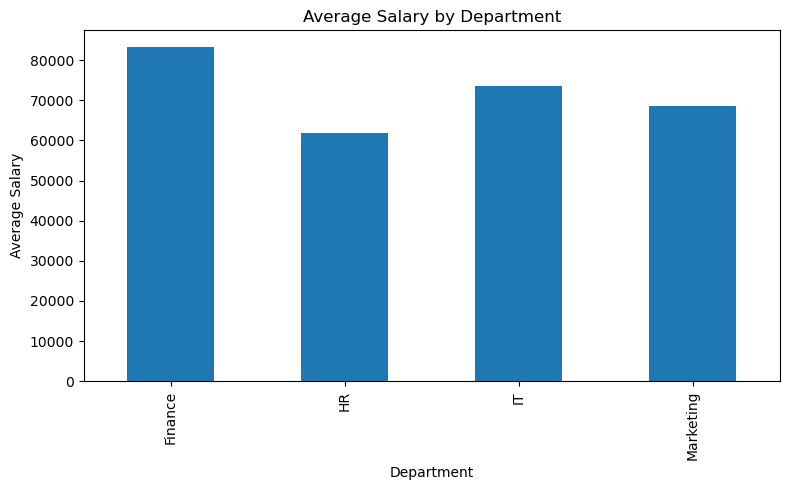

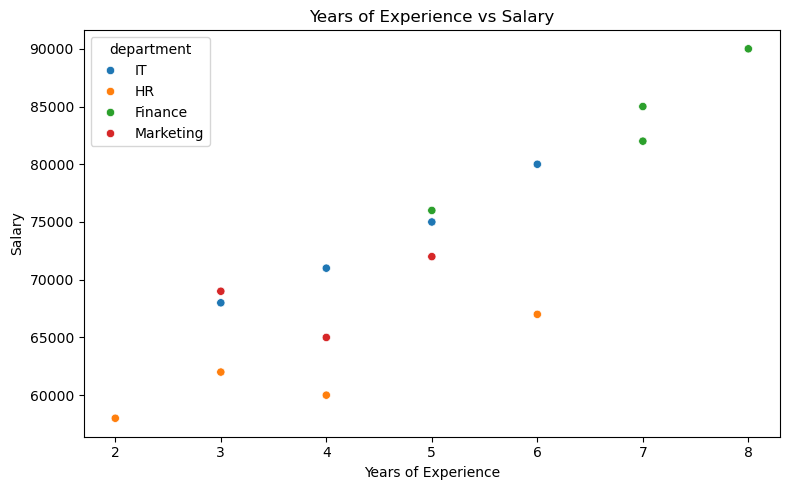

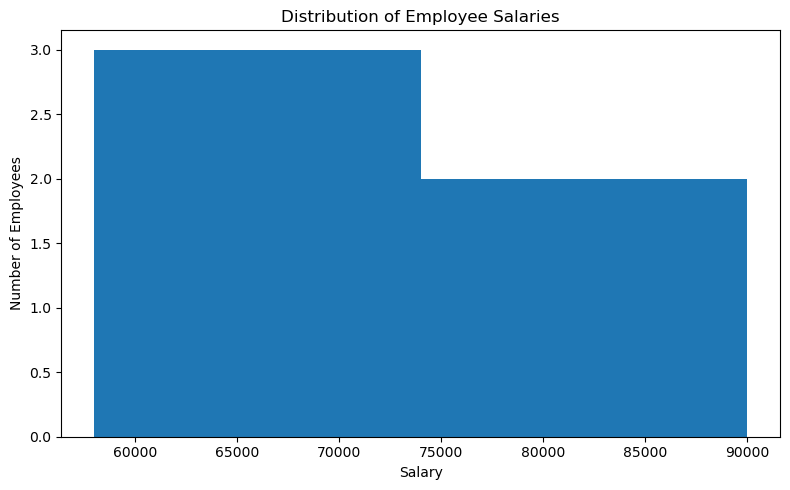

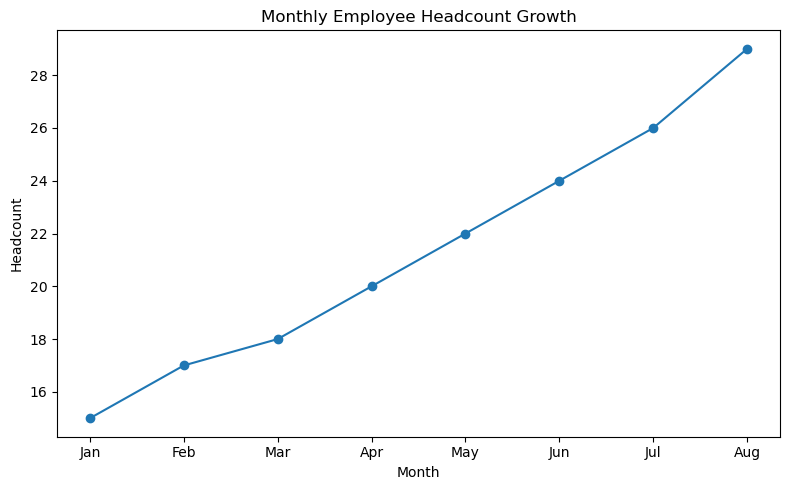

In [9]:
# Task 4 - Tell a Story

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load employee data
employees = pd.read_csv("employees.csv")

employees["salary"] = employees["salary"].fillna(
    employees["salary"].mean()
)

average_salary = employees.groupby("department")["salary"].mean()

plt.figure(figsize=(8, 5))

average_salary.plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=employees,
    x="years_experience",
    y="salary",
    hue="department"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.hist(
    employees["salary"],
    bins=6
)

plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


monthly_data = pd.DataFrame({
    "month": [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug"
    ],
    "headcount": [
        15, 17, 18, 20,
        22, 24, 26, 29
    ]
})

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_data["month"],
    monthly_data["headcount"],
    marker="o"
)

plt.title("Monthly Employee Headcount Growth")
plt.xlabel("Month")
plt.ylabel("Headcount")

plt.tight_layout()
plt.show()


In [15]:
# Task 5 - Consolidation Reflection


### 1. Java habits I had to unlearn or adjust

#**OOP — Master Class 4:**
    #I had to adjust my Java habit of using explicit getters, setters, and interfaces everywhere. In Python, concepts such as duck typing, direct attribute access, and dunder methods like `__str__` and `__eq__` provide simpler ways to design classes.

#**FastAPI/Testing — Master Class 5:**
    #I had to adjust my Java habit of relying heavily on annotations and framework configuration. With FastAPI, I learned to use Python type hints and Pydantic models for request validation, and testing can be done directly with tools such as `TestClient` and `pytest`.

#**Pandas/NumPy — Master Class 6:**
    #I had to unlearn the habit of processing data mainly with `for` loops. NumPy supports vectorized operations and Pandas provides filtering, `groupby()`, aggregation, and merging, which allow data to be processed more efficiently and concisely.

### 2. Skill I expect to use again

    #One skill I expect to use frequently is **DataFrame filtering and NumPy vectorization**. In upcoming ML/DL modules, datasets will need to be cleaned, filtered, transformed, and prepared before training models, so operations such as boolean masking, handling missing values, and vectorized calculations will be useful during data preprocessing.

### 3. Least confident topic and improvement plan

    #The topic I feel least confident about is **Pandas merging and handling missing data**, especially understanding the differences between inner and left joins and deciding when to use `dropna()` versus `fillna()`. Before the readiness assessment, I will practice several small datasets using `merge()`, `.isna().sum()`, `dropna()`, and `fillna()` and verify the results myself.


In [16]:
# Task 6 - Readiness Self-Check

class TrainingRun:

    def __init__(self, model_name, learning_rate):
        self.model_name = model_name
        self.learning_rate = learning_rate

    def __str__(self):
        return f"TrainingRun(model={self.model_name}, lr={self.learning_rate})"


my_run = TrainingRun("CNN", 0.001)
print(my_run)

TrainingRun(model=CNN, lr=0.001)


In [26]:


from fastapi import FastAPI
from pydantic import BaseModel

print("FastAPI imported successfully!")

app = FastAPI()


class User(BaseModel):
    name: str
    age: int


@app.post("/users")
def create_user(user: User):
    return user

FastAPI imported successfully!


In [18]:
import pandas as pd

df = pd.read_csv("employees.csv")

summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)

print(summary)

            average_salary  headcount
department                           
Finance       83250.000000          4
HR            61750.000000          4
IT            73500.000000          4
Marketing     68666.666667          3
